In [77]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [78]:
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [79]:
df = pd.read_csv("./drive/MyDrive/datasets/alzheimers_disease_data.csv")

pd.set_option("display.max_columns", None) # Display all the available columns 
df.head(10)


,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,FamilyHistoryAlzheimers,CardiovascularDisease,Diabetes,Depression,HeadInjury,Hypertension,SystolicBP,DiastolicBP,CholesterolTotal,CholesterolLDL,CholesterolHDL,CholesterolTriglycerides,MMSE,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
0,4751,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,9.025679,0,0,1,1,0,0,142,72,242.366840,56.150897,33.682563,162.189143,21.463532,6.518877,0,0,1.725883,0,0,0,1,0,0,XXXConfid
1,4752,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,7.151293,0,0,0,0,0,0,115,64,231.162595,193.407996,79.028477,294.630909,20.613267,7.118696,0,0,2.592424,0,0,0,0,1,0,XXXConfid
2,4753,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,9.673574,1,0,0,0,0,0,99,116,284.181858,153.322762,69.772292,83.638324,7.356249,5.895077,0,0,7.119548,0,1,0,1,0,0,XXXConfid
3,4754,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,8.392554,0,0,0,0,0,0,118,115,159.582240,65.366637,68.457491,277.577358,13.991127,8.965106,0,1,6.481226,0,0,0,0,0,0,XXXConfid
4,4755,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,5.597238,0,0,0,0,0,0,94,117,237.602184,92.869700,56.874305,291.198780,13.517609,6.045039,0,0,0.014691,0,0,1,1,0,0,XXXConfid
5,4756,86,1,1,1,30.626886,0,4.140144,0.211062,1.584922,7.261953,0,0,1,0,0,0,168,62,280.712539,198.334629,79.080503,263.943655,27.517529,5.510144,0,0,9.015686,1,0,0,0,0,0,XXXConfid
6,4757,68,0,3,2,38.387622,1,0.646047,9.257695,5.897388,5.477686,0,0,0,0,1,0,143,88,263.734149,52.470670,66.533369,216.489175,1.964413,6.062124,0,0,9.236328,0,0,0,0,1,0,XXXConfid
7,4758,75,0,0,1,18.776009,0,13.723826,4.649451,8.341903,4.213210,0,0,0,0,0,0,117,63,151.383137,69.623510,77.346816,210.570866,10.139568,3.401374,0,0,4.517248,1,0,0,0,1,1,XXXConfid
8,4759,72,1,1,0,27.833188,0,12.167848,1.531360,6.736882,5.748224,0,0,0,0,0,1,117,119,233.605755,144.045740,43.075893,151.164186,25.820732,7.396061,0,1,0.756232,0,0,1,0,0,0,XXXConfid
9,4760,87,0,0,0,35.456302,1,16.028688,6.440773,8.086019,7.551773,0,1,0,0,0,0,130,78,281.630050,130.497580,74.291247,144.175975,28.388409,1.148904,0,1,4.554394,0,0,0,0,0,0,XXXConfid


In [80]:
df.tail(10)

,PatientID,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,FamilyHistoryAlzheimers,CardiovascularDisease,Diabetes,Depression,HeadInjury,Hypertension,SystolicBP,DiastolicBP,CholesterolTotal,CholesterolLDL,CholesterolHDL,CholesterolTriglycerides,MMSE,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,DoctorInCharge
2139,6890,68,0,1,0,17.828965,0,2.982747,8.394826,0.317526,5.736780,0,0,0,1,1,0,102,61,236.649402,173.902699,48.917216,334.385731,10.828250,9.104117,0,0,8.819115,0,0,0,1,0,0,XXXConfid
2140,6891,89,0,1,2,34.422419,0,7.770687,0.947567,5.732139,4.917760,0,1,0,0,0,1,142,78,227.111228,58.548910,28.587889,187.789339,4.926400,1.605154,0,0,8.734082,0,1,0,0,0,0,XXXConfid
2141,6892,72,0,0,2,21.600144,0,19.391766,8.181469,6.640195,7.088091,1,0,0,0,0,0,137,91,264.994941,181.683521,96.361322,347.479619,20.013786,8.722739,0,0,9.570776,0,0,0,0,1,0,XXXConfid
2142,6893,88,0,0,0,20.097600,0,4.089458,7.389633,2.878738,6.271699,0,0,0,0,0,1,166,105,190.975712,104.920573,36.593711,81.075130,25.140903,7.729270,0,0,6.156040,0,0,0,1,0,1,XXXConfid
2143,6894,66,1,2,1,32.013806,1,9.308706,4.352402,5.432374,9.624312,1,0,0,0,0,1,101,99,233.954108,57.454170,67.162675,98.688095,5.903689,1.405821,0,0,4.544538,0,0,0,1,1,1,XXXConfid
2144,6895,61,0,0,1,39.121757,0,1.561126,4.049964,6.555306,7.535540,0,0,0,0,0,0,122,101,280.476824,94.870490,60.943092,234.520123,1.201190,0.238667,0,0,4.492838,1,0,0,0,0,1,XXXConfid
2145,6896,75,0,0,2,17.857903,0,18.767261,1.360667,2.904662,8.555256,0,0,0,0,0,0,152,106,186.384436,95.410700,93.649735,367.986877,6.458060,8.687480,0,1,9.204952,0,0,0,0,0,1,XXXConfid
2146,6897,77,0,0,1,15.476479,0,4.594670,9.886002,8.120025,5.769464,0,0,0,0,0,0,115,118,237.024558,156.267294,99.678209,294.802338,17.011003,1.972137,0,0,5.036334,0,0,0,0,0,1,XXXConfid
2147,6898,78,1,3,1,15.299911,0,8.674505,6.354282,1.263427,8.322874,0,1,0,0,0,0,103,96,242.197192,52.482961,81.281111,145.253746,4.030491,5.173891,0,0,3.785399,0,0,0,0,1,1,XXXConfid
2148,6899,72,0,0,2,33.289738,0,7.890703,6.570993,7.941404,9.878711,0,0,0,0,0,0,166,78,283.396797,92.200064,81.920043,217.396873,11.114777,6.307543,0,1,8.327563,0,1,0,0,1,0,XXXConfid


In [81]:
df.shape

(2149, 35)

In [82]:
df.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 35 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   PatientID                  2149 non-null   int64  
 1   Age                        2149 non-null   int64  
 2   Gender                     2149 non-null   int64  
 3   Ethnicity                  2149 non-null   int64  
 4   EducationLevel             2149 non-null   int64  
 5   BMI                        2149 non-null   float64
 6   Smoking                    2149 non-null   int64  
 7   AlcoholConsumption         2149 non-null   float64
 8   PhysicalActivity           2149 non-null   float64
 9   DietQuality                2149 non-null   float64
 10  SleepQuality               2149 non-null   float64
 11  FamilyHistoryAlzheimers    2149 non-null   int64  
 12  CardiovascularDisease      2149 non-null   int64  
 13  Diabetes                   2149 non-null   int64

In [83]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
PatientID,2149.0,5825.000000,620.507185,4751.000000,5288.000000,5825.000000,6362.000000,6899.000000
Age,2149.0,74.908795,8.990221,60.000000,67.000000,75.000000,83.000000,90.000000
Gender,2149.0,0.506282,0.500077,0.000000,0.000000,1.000000,1.000000,1.000000
Ethnicity,2149.0,0.697534,0.996128,0.000000,0.000000,0.000000,1.000000,3.000000
EducationLevel,2149.0,1.286645,0.904527,0.000000,1.000000,1.000000,2.000000,3.000000
BMI,2149.0,27.655697,7.217438,15.008851,21.611408,27.823924,33.869778,39.992767
Smoking,2149.0,0.288506,0.453173,0.000000,0.000000,0.000000,1.000000,1.000000
AlcoholConsumption,2149.0,10.039442,5.757910,0.002003,5.139810,9.934412,15.157931,19.989293
PhysicalActivity,2149.0,4.920202,2.857191,0.003616,2.570626,4.766424,7.427899,9.987429
DietQuality,2149.0,4.993138,2.909055,0.009385,2.458455,5.076087,7.558625,9.998346


In [84]:
# Checking Null Values

df.isna().sum()

,0
PatientID,0
Age,0
Gender,0
Ethnicity,0
EducationLevel,0
BMI,0
Smoking,0
AlcoholConsumption,0
PhysicalActivity,0
DietQuality,0


In [85]:
# Drop the PatientID and DoctorInCharge

df_alzheimers = df.drop(columns=["PatientID", "DoctorInCharge",])

df_alzheimers.head(10)

,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,FamilyHistoryAlzheimers,CardiovascularDisease,Diabetes,Depression,HeadInjury,Hypertension,SystolicBP,DiastolicBP,CholesterolTotal,CholesterolLDL,CholesterolHDL,CholesterolTriglycerides,MMSE,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
0,73,0,0,2,22.927749,0,13.297218,6.327112,1.347214,9.025679,0,0,1,1,0,0,142,72,242.366840,56.150897,33.682563,162.189143,21.463532,6.518877,0,0,1.725883,0,0,0,1,0,0
1,89,0,0,0,26.827681,0,4.542524,7.619885,0.518767,7.151293,0,0,0,0,0,0,115,64,231.162595,193.407996,79.028477,294.630909,20.613267,7.118696,0,0,2.592424,0,0,0,0,1,0
2,73,0,3,1,17.795882,0,19.555085,7.844988,1.826335,9.673574,1,0,0,0,0,0,99,116,284.181858,153.322762,69.772292,83.638324,7.356249,5.895077,0,0,7.119548,0,1,0,1,0,0
3,74,1,0,1,33.800817,1,12.209266,8.428001,7.435604,8.392554,0,0,0,0,0,0,118,115,159.582240,65.366637,68.457491,277.577358,13.991127,8.965106,0,1,6.481226,0,0,0,0,0,0
4,89,0,0,0,20.716974,0,18.454356,6.310461,0.795498,5.597238,0,0,0,0,0,0,94,117,237.602184,92.869700,56.874305,291.198780,13.517609,6.045039,0,0,0.014691,0,0,1,1,0,0
5,86,1,1,1,30.626886,0,4.140144,0.211062,1.584922,7.261953,0,0,1,0,0,0,168,62,280.712539,198.334629,79.080503,263.943655,27.517529,5.510144,0,0,9.015686,1,0,0,0,0,0
6,68,0,3,2,38.387622,1,0.646047,9.257695,5.897388,5.477686,0,0,0,0,1,0,143,88,263.734149,52.470670,66.533369,216.489175,1.964413,6.062124,0,0,9.236328,0,0,0,0,1,0
7,75,0,0,1,18.776009,0,13.723826,4.649451,8.341903,4.213210,0,0,0,0,0,0,117,63,151.383137,69.623510,77.346816,210.570866,10.139568,3.401374,0,0,4.517248,1,0,0,0,1,1
8,72,1,1,0,27.833188,0,12.167848,1.531360,6.736882,5.748224,0,0,0,0,0,1,117,119,233.605755,144.045740,43.075893,151.164186,25.820732,7.396061,0,1,0.756232,0,0,1,0,0,0
9,87,0,0,0,35.456302,1,16.028688,6.440773,8.086019,7.551773,0,1,0,0,0,0,130,78,281.630050,130.497580,74.291247,144.175975,28.388409,1.148904,0,1,4.554394,0,0,0,0,0,0


In [86]:
df_alzheimers.info(verbose=True)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2149 entries, 0 to 2148
Data columns (total 33 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Age                        2149 non-null   int64  
 1   Gender                     2149 non-null   int64  
 2   Ethnicity                  2149 non-null   int64  
 3   EducationLevel             2149 non-null   int64  
 4   BMI                        2149 non-null   float64
 5   Smoking                    2149 non-null   int64  
 6   AlcoholConsumption         2149 non-null   float64
 7   PhysicalActivity           2149 non-null   float64
 8   DietQuality                2149 non-null   float64
 9   SleepQuality               2149 non-null   float64
 10  FamilyHistoryAlzheimers    2149 non-null   int64  
 11  CardiovascularDisease      2149 non-null   int64  
 12  Diabetes                   2149 non-null   int64  
 13  Depression                 2149 non-null   int64

In [87]:
target_col = "Diagnosis"

numeric_cols = ["BMI", "AlcoholConsumption", "PhysicalActivity",
    "DietQuality", "SleepQuality", "SystolicBP", "DiastolicBP",
    "CholesterolTotal", "CholesterolLDL", "CholesterolHDL",
    "CholesterolTriglycerides", "MMSE", "FunctionalAssessment", "ADL",]


categorical_cols = ["Age", "Gender", "Ethnicity", "EducationLevel", "Smoking", "FamilyHistoryAlzheimers",
    "CardiovascularDisease", "Diabetes", "Depression", "HeadInjury",
    "Hypertension", "MemoryComplaints", "BehavioralProblems",
    "Confusion", "Disorientation", "PersonalityChanges",
    "DifficultyCompletingTasks", "Forgetfulness",]


print("Target Columns: ", target_col)
print("Numeric Columns: ", numeric_cols)
print("Categorical Columns: ", categorical_cols)

Target Columns:  Diagnosis
Numeric Columns:  ['BMI', 'AlcoholConsumption', 'PhysicalActivity', 'DietQuality', 'SleepQuality', 'SystolicBP', 'DiastolicBP', 'CholesterolTotal', 'CholesterolLDL', 'CholesterolHDL', 'CholesterolTriglycerides', 'MMSE', 'FunctionalAssessment', 'ADL']
Categorical Columns:  ['Age', 'Gender', 'Ethnicity', 'EducationLevel', 'Smoking', 'FamilyHistoryAlzheimers', 'CardiovascularDisease', 'Diabetes', 'Depression', 'HeadInjury', 'Hypertension', 'MemoryComplaints', 'BehavioralProblems', 'Confusion', 'Disorientation', 'PersonalityChanges', 'DifficultyCompletingTasks', 'Forgetfulness']


In [88]:
df_alzheimers[numeric_cols].agg(["min", "max", "mean", "median"]).T

,min,max,mean,median
BMI,15.008851,39.992767,27.655697,27.823924
AlcoholConsumption,0.002003,19.989293,10.039442,9.934412
PhysicalActivity,0.003616,9.987429,4.920202,4.766424
DietQuality,0.009385,9.998346,4.993138,5.076087
SleepQuality,4.002629,9.999840,7.051081,7.115646
SystolicBP,90.000000,179.000000,134.264774,134.000000
DiastolicBP,60.000000,119.000000,89.847836,91.000000
CholesterolTotal,150.093316,299.993352,225.197519,225.086430
CholesterolLDL,50.230707,199.965665,124.335944,123.342593
CholesterolHDL,20.003434,99.980324,59.463533,59.768237


In [89]:
for c in categorical_cols:
    print(c, df_alzheimers[c].unique())

Age [73 89 74 86 68 75 72 87 78 84 64 69 63 65 82 77 71 83 79 67 66 70 85 60
 88 62 81 61 80 90 76]
Gender [0 1]
Ethnicity [0 3 1 2]
EducationLevel [2 0 1 3]
Smoking [0 1]
FamilyHistoryAlzheimers [0 1]
CardiovascularDisease [0 1]
Diabetes [1 0]
Depression [1 0]
HeadInjury [0 1]
Hypertension [0 1]
MemoryComplaints [0 1]
BehavioralProblems [0 1]
Confusion [0 1]
Disorientation [0 1]
PersonalityChanges [0 1]
DifficultyCompletingTasks [1 0]
Forgetfulness [0 1]


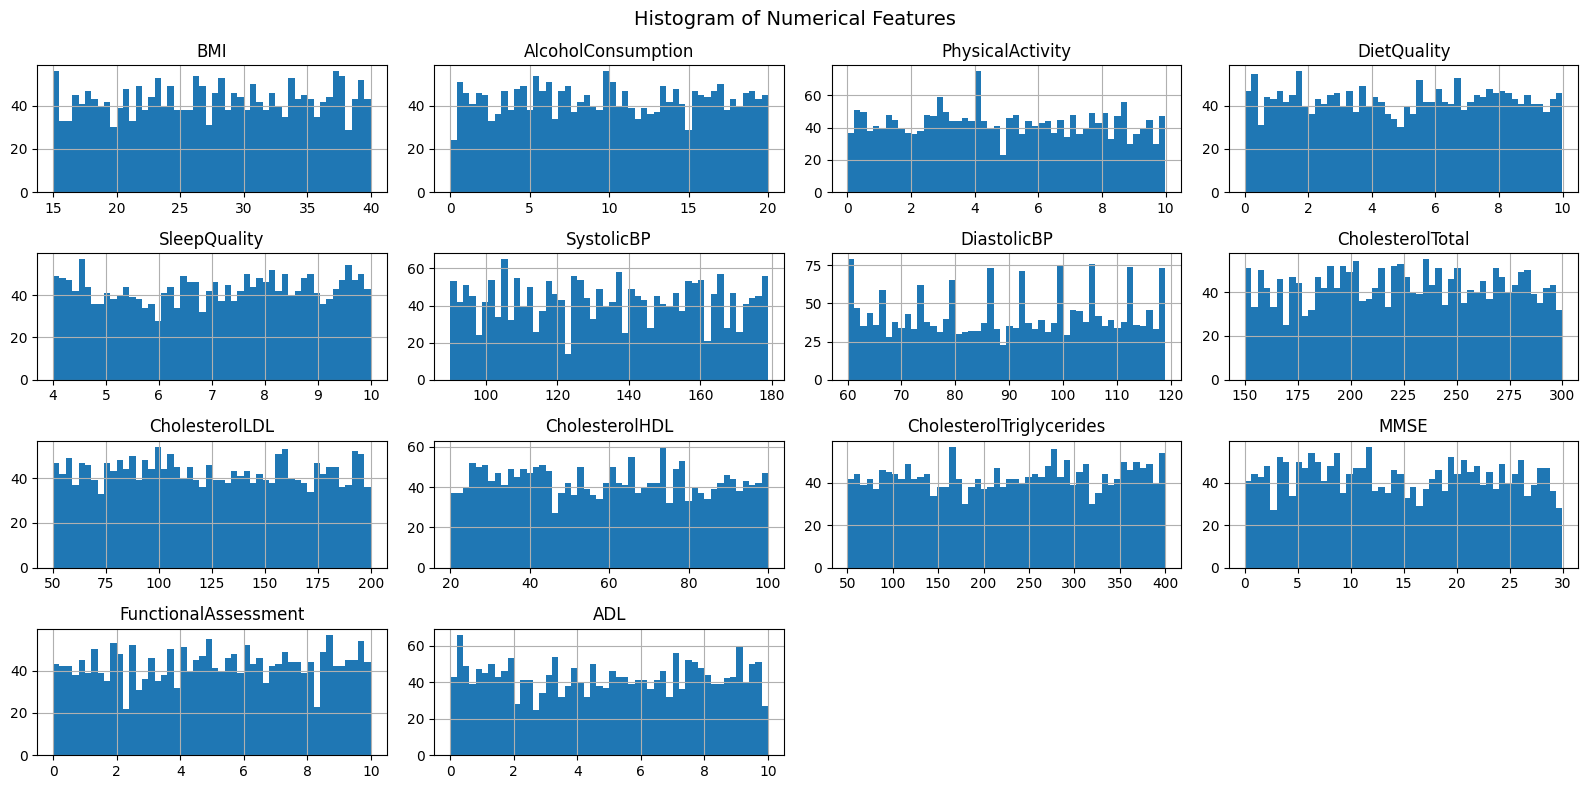

In [90]:
df_alzheimers[numeric_cols].hist(bins=50, figsize=(16, 8))
plt.suptitle("Histogram of Numerical Features", fontsize=14)
plt.tight_layout()
plt.show()

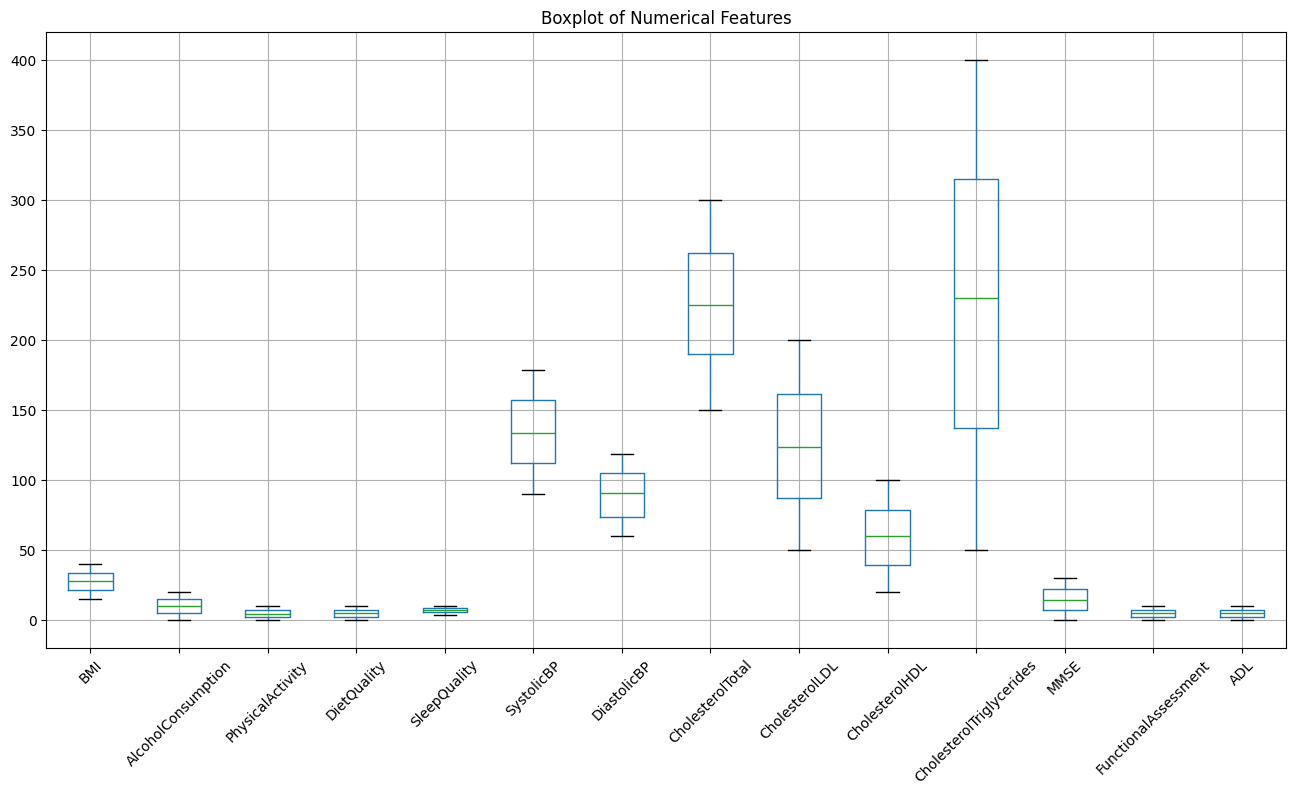

In [91]:
plt.figure(figsize=(16, 8))
df_alzheimers[numeric_cols].boxplot()
plt.title("Boxplot of Numerical Features")
plt.xticks(rotation=45)
plt.show()

### Categorical Feature Exploration

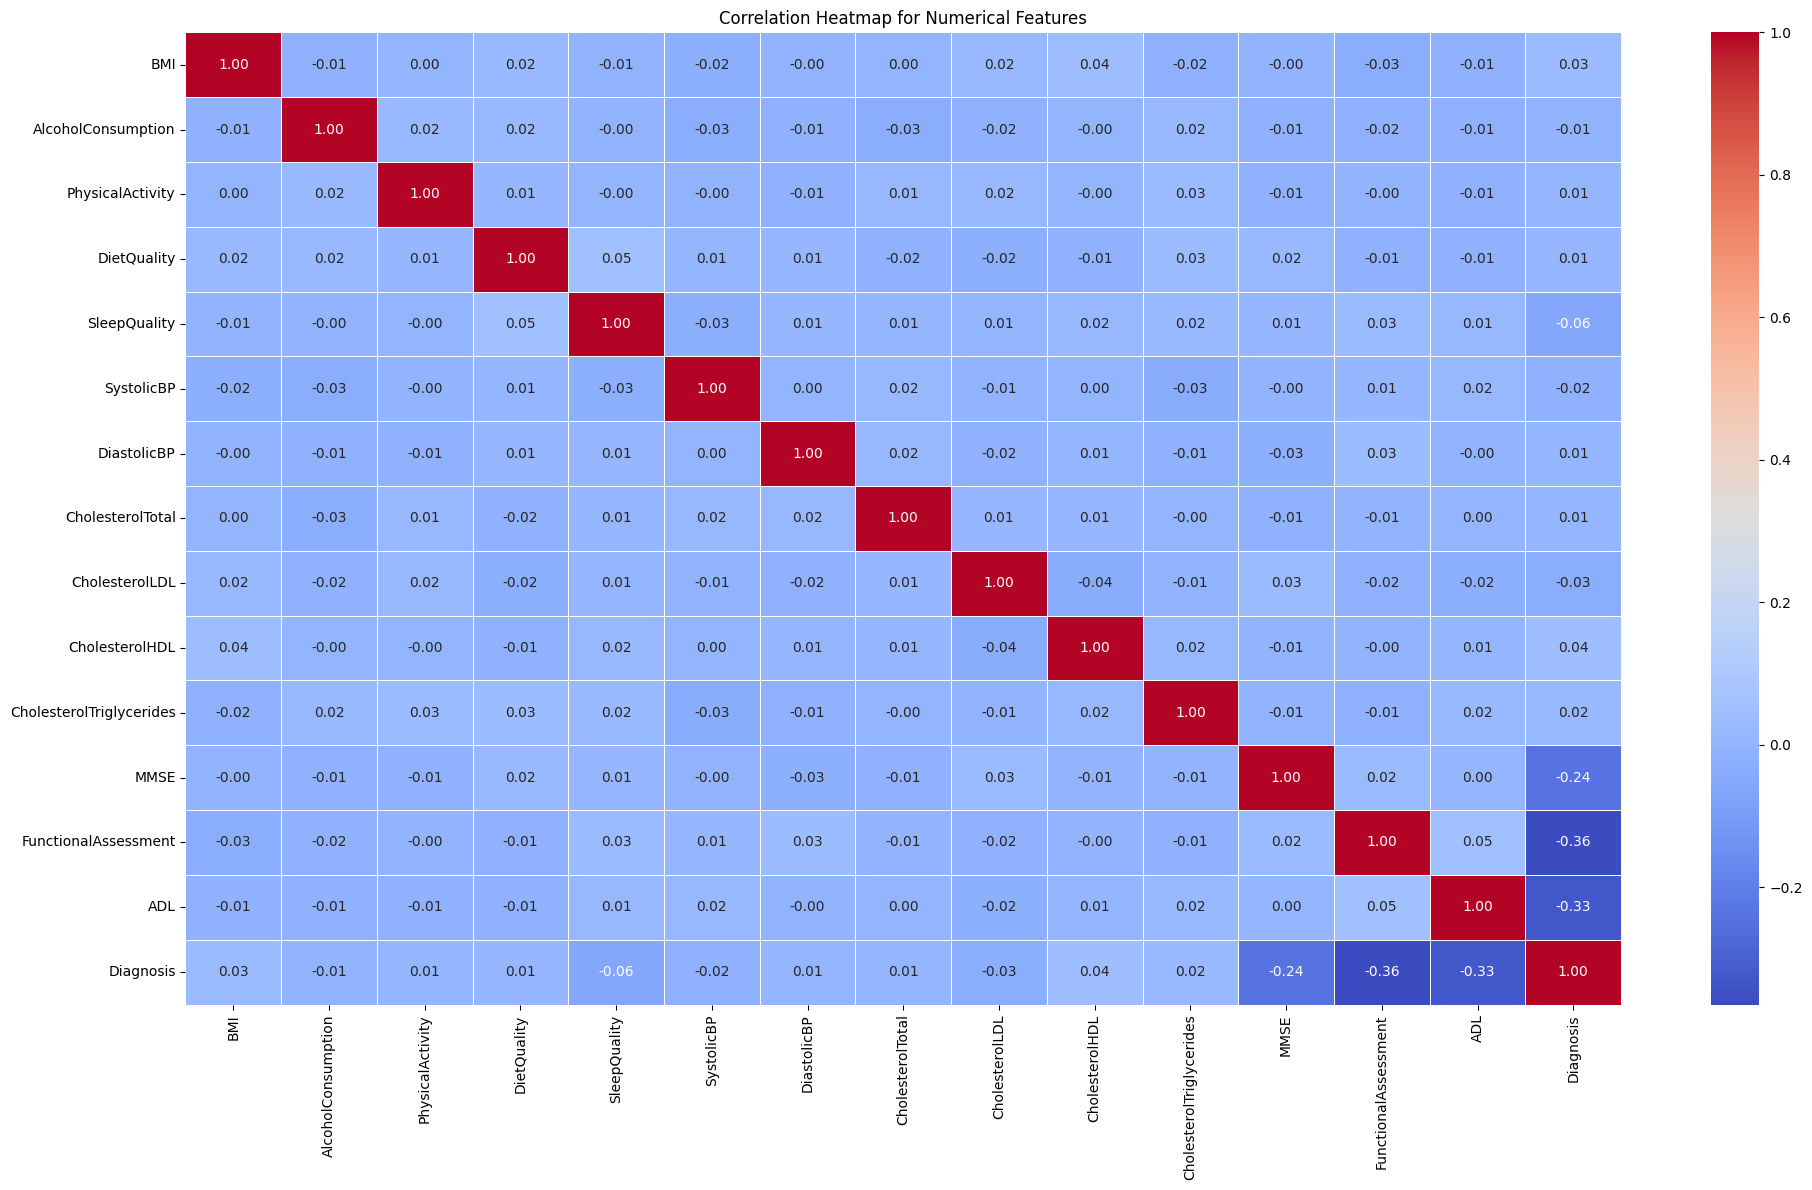

In [92]:
corr_matrix = df_alzheimers[numeric_cols + [target_col]].corr()

plt.figure(figsize=(20, 12))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap for Numerical Features")
plt.tight_layout()
plt.show()


# Class Imbalance

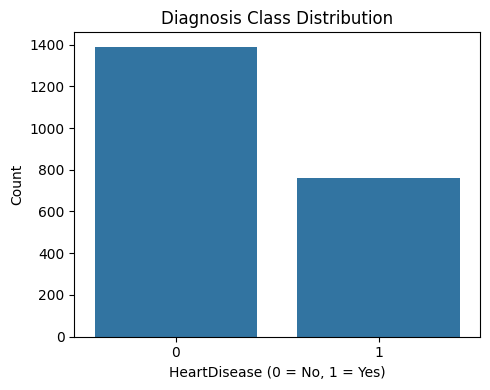

In [93]:
plt.figure(figsize=(5,4))
sns.countplot(x=df_alzheimers[target_col])
plt.title("Diagnosis Class Distribution")
plt.xlabel("HeartDisease (0 = No, 1 = Yes)")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [94]:
df[target_col].value_counts(normalize=True)

,proportion
Diagnosis,
0,0.646347
1,0.353653


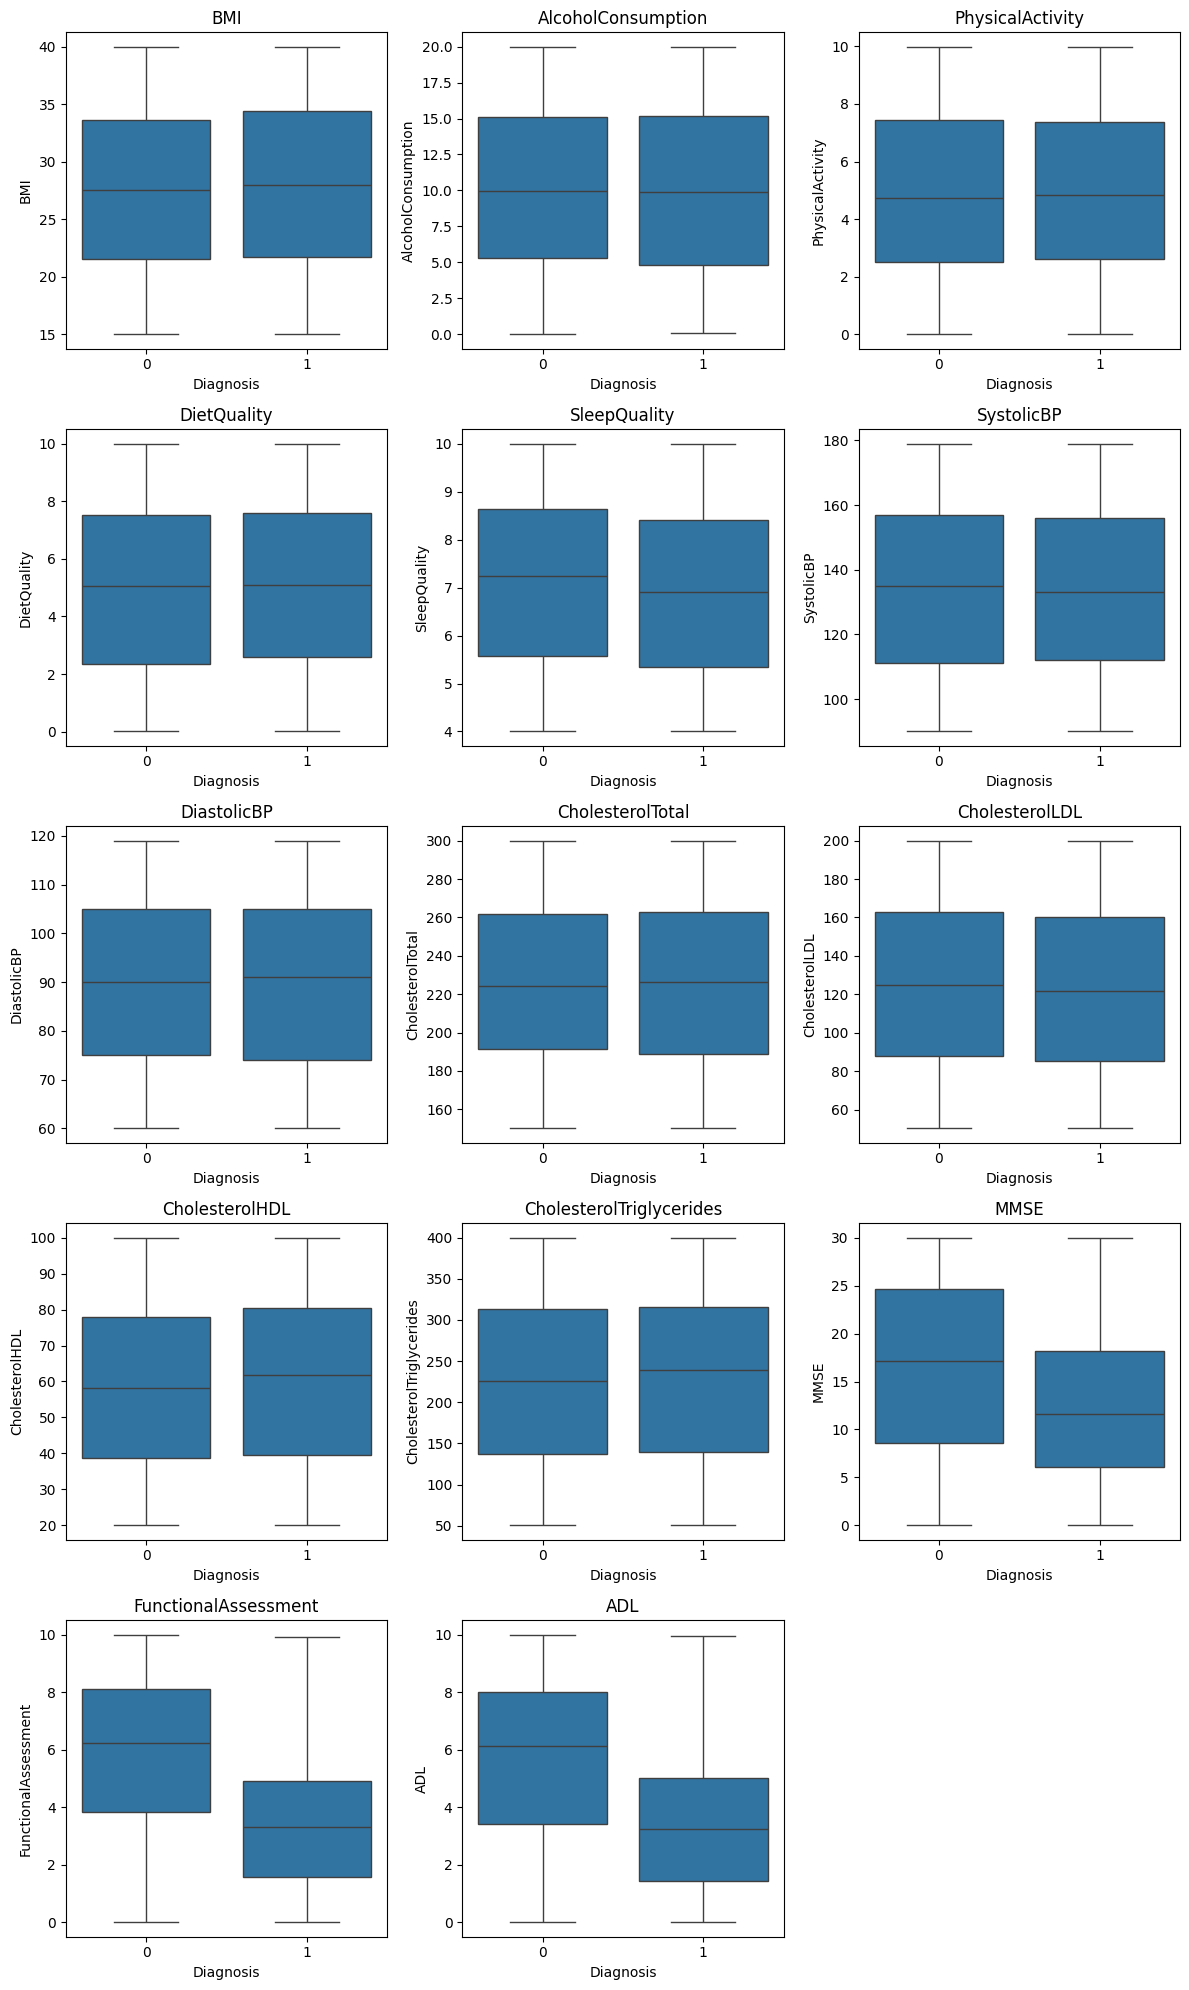

In [95]:
import math

cols_per_row = 3
total_plots = len(numeric_cols)

num_rows = math.ceil(total_plots / cols_per_row)

plt.figure(figsize=(12, 4 * num_rows)) 

for i, col in enumerate(numeric_cols, 1):
    plt.subplot(num_rows, cols_per_row, i)
    sns.boxplot(x=df_alzheimers[target_col], y=df_alzheimers[col])
    plt.title(col)

plt.tight_layout()
plt.show()

In [96]:
df_alzheimers.dtypes

,0
Age,int64
Gender,int64
Ethnicity,int64
EducationLevel,int64
BMI,float64
Smoking,int64
AlcoholConsumption,float64
PhysicalActivity,float64
DietQuality,float64
SleepQuality,float64


### Encoding

In [97]:
from sklearn.preprocessing import LabelEncoder

In [98]:
le = LabelEncoder()

df_alzheimers["Gender"] = le.fit_transform(df_alzheimers["Gender"])
df_alzheimers["Smoking"] = le.fit_transform(df_alzheimers["Smoking"])
df_alzheimers["PhysicalActivity"] = le.fit_transform(df_alzheimers["PhysicalActivity"])

In [99]:
df_alzheimers.head(10)

,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,FamilyHistoryAlzheimers,CardiovascularDisease,Diabetes,Depression,HeadInjury,Hypertension,SystolicBP,DiastolicBP,CholesterolTotal,CholesterolLDL,CholesterolHDL,CholesterolTriglycerides,MMSE,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis
0,73,0,0,2,22.927749,0,13.297218,1388,1.347214,9.025679,0,0,1,1,0,0,142,72,242.366840,56.150897,33.682563,162.189143,21.463532,6.518877,0,0,1.725883,0,0,0,1,0,0
1,89,0,0,0,26.827681,0,4.542524,1653,0.518767,7.151293,0,0,0,0,0,0,115,64,231.162595,193.407996,79.028477,294.630909,20.613267,7.118696,0,0,2.592424,0,0,0,0,1,0
2,73,0,3,1,17.795882,0,19.555085,1703,1.826335,9.673574,1,0,0,0,0,0,99,116,284.181858,153.322762,69.772292,83.638324,7.356249,5.895077,0,0,7.119548,0,1,0,1,0,0
3,74,1,0,1,33.800817,1,12.209266,1825,7.435604,8.392554,0,0,0,0,0,0,118,115,159.582240,65.366637,68.457491,277.577358,13.991127,8.965106,0,1,6.481226,0,0,0,0,0,0
4,89,0,0,0,20.716974,0,18.454356,1381,0.795498,5.597238,0,0,0,0,0,0,94,117,237.602184,92.869700,56.874305,291.198780,13.517609,6.045039,0,0,0.014691,0,0,1,1,0,0
5,86,1,1,1,30.626886,0,4.140144,40,1.584922,7.261953,0,0,1,0,0,0,168,62,280.712539,198.334629,79.080503,263.943655,27.517529,5.510144,0,0,9.015686,1,0,0,0,0,0
6,68,0,3,2,38.387622,1,0.646047,1999,5.897388,5.477686,0,0,0,0,1,0,143,88,263.734149,52.470670,66.533369,216.489175,1.964413,6.062124,0,0,9.236328,0,0,0,0,1,0
7,75,0,0,1,18.776009,0,13.723826,1057,8.341903,4.213210,0,0,0,0,0,0,117,63,151.383137,69.623510,77.346816,210.570866,10.139568,3.401374,0,0,4.517248,1,0,0,0,1,1
8,72,1,1,0,27.833188,0,12.167848,334,6.736882,5.748224,0,0,0,0,0,1,117,119,233.605755,144.045740,43.075893,151.164186,25.820732,7.396061,0,1,0.756232,0,0,1,0,0,0
9,87,0,0,0,35.456302,1,16.028688,1414,8.086019,7.551773,0,1,0,0,0,0,130,78,281.630050,130.497580,74.291247,144.175975,28.388409,1.148904,0,1,4.554394,0,0,0,0,0,0


In [100]:
categorical_cols = ["CardiovascularDisease", "Hypertension", "Smoking", "FamilyHistoryAlzheimers", "HeadInjury", "Depression", "Diabetes"]

df_alzheimers_encoded = pd.get_dummies(
    df_alzheimers,
    columns=categorical_cols,
    dtype=int
)

In [101]:
df_alzheimers_encoded.head(10)

,Age,Gender,Ethnicity,EducationLevel,BMI,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,SystolicBP,DiastolicBP,CholesterolTotal,CholesterolLDL,CholesterolHDL,CholesterolTriglycerides,MMSE,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,Diagnosis,CardiovascularDisease_0,CardiovascularDisease_1,Hypertension_0,Hypertension_1,Smoking_0,Smoking_1,FamilyHistoryAlzheimers_0,FamilyHistoryAlzheimers_1,HeadInjury_0,HeadInjury_1,Depression_0,Depression_1,Diabetes_0,Diabetes_1
0,73,0,0,2,22.927749,13.297218,1388,1.347214,9.025679,142,72,242.366840,56.150897,33.682563,162.189143,21.463532,6.518877,0,0,1.725883,0,0,0,1,0,0,1,0,1,0,1,0,1,0,1,0,0,1,0,1
1,89,0,0,0,26.827681,4.542524,1653,0.518767,7.151293,115,64,231.162595,193.407996,79.028477,294.630909,20.613267,7.118696,0,0,2.592424,0,0,0,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0
2,73,0,3,1,17.795882,19.555085,1703,1.826335,9.673574,99,116,284.181858,153.322762,69.772292,83.638324,7.356249,5.895077,0,0,7.119548,0,1,0,1,0,0,1,0,1,0,1,0,0,1,1,0,1,0,1,0
3,74,1,0,1,33.800817,12.209266,1825,7.435604,8.392554,118,115,159.582240,65.366637,68.457491,277.577358,13.991127,8.965106,0,1,6.481226,0,0,0,0,0,0,1,0,1,0,0,1,1,0,1,0,1,0,1,0
4,89,0,0,0,20.716974,18.454356,1381,0.795498,5.597238,94,117,237.602184,92.869700,56.874305,291.198780,13.517609,6.045039,0,0,0.014691,0,0,1,1,0,0,1,0,1,0,1,0,1,0,1,0,1,0,1,0
5,86,1,1,1,30.626886,4.140144,40,1.584922,7.261953,168,62,280.712539,198.334629,79.080503,263.943655,27.517529,5.510144,0,0,9.015686,1,0,0,0,0,0,1,0,1,0,1,0,1,0,1,0,1,0,0,1
6,68,0,3,2,38.387622,0.646047,1999,5.897388,5.477686,143,88,263.734149,52.470670,66.533369,216.489175,1.964413,6.062124,0,0,9.236328,0,0,0,0,1,0,1,0,1,0,0,1,1,0,0,1,1,0,1,0
7,75,0,0,1,18.776009,13.723826,1057,8.341903,4.213210,117,63,151.383137,69.623510,77.346816,210.570866,10.139568,3.401374,0,0,4.517248,1,0,0,0,1,1,1,0,1,0,1,0,1,0,1,0,1,0,1,0
8,72,1,1,0,27.833188,12.167848,334,6.736882,5.748224,117,119,233.605755,144.045740,43.075893,151.164186,25.820732,7.396061,0,1,0.756232,0,0,1,0,0,0,1,0,0,1,1,0,1,0,1,0,1,0,1,0
9,87,0,0,0,35.456302,16.028688,1414,8.086019,7.551773,130,78,281.630050,130.497580,74.291247,144.175975,28.388409,1.148904,0,1,4.554394,0,0,0,0,0,0,0,1,1,0,0,1,1,0,1,0,1,0,1,0


### Scaling

In [102]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [103]:
X = df_alzheimers_encoded.drop(columns=[target_col])
y = df_alzheimers_encoded[target_col]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.25, random_state=42)

##### Standard Scaling


In [104]:
scalar_sd = StandardScaler()
X_train_std = scalar_sd.fit_transform(X_train)
X_test_std = scalar_sd.transform(X_test)

X_train_std_df = pd.DataFrame(X_train_std, columns= X_train.columns, index=X_train.index)
X_test_std_df = pd.DataFrame(X_test_std, columns=X_test.columns, index=X_test.index)

print("Train: ")
display(X_train_std_df.head(10))

print("Test: ")
display(X_test_std_df.head(10))


Train: 


,Age,Gender,Ethnicity,EducationLevel,BMI,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,SystolicBP,DiastolicBP,CholesterolTotal,CholesterolLDL,CholesterolHDL,CholesterolTriglycerides,MMSE,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,CardiovascularDisease_0,CardiovascularDisease_1,Hypertension_0,Hypertension_1,Smoking_0,Smoking_1,FamilyHistoryAlzheimers_0,FamilyHistoryAlzheimers_1,HeadInjury_0,HeadInjury_1,Depression_0,Depression_1,Diabetes_0,Diabetes_1
552,-1.100808,-0.998140,0.288706,-0.311088,-1.641911,-0.652140,1.075090,-0.895456,1.303114,-1.303049,-1.535665,0.704761,-0.595330,0.536285,-0.076537,0.987818,0.933500,-0.508521,-0.426558,0.990639,-0.499806,-0.435670,-0.415318,-0.436678,1.541869,0.393496,-0.393496,0.425541,-0.425541,0.628335,-0.628335,0.576634,-0.576634,0.328600,-0.328600,-1.929855,1.929855,0.424523,-0.424523
1490,-1.652650,-0.998140,0.288706,1.896676,0.127347,-0.446875,1.233475,0.301843,-1.466694,-0.913758,-1.422694,-0.722575,0.446379,1.740686,0.721243,1.705150,1.654654,1.966487,-0.426558,-1.574089,-0.499806,2.295318,-0.415318,-0.436678,1.541869,0.393496,-0.393496,0.425541,-0.425541,0.628335,-0.628335,-1.734204,1.734204,-3.043213,3.043213,-1.929855,1.929855,-2.355585,2.355585
315,0.554720,1.001864,-0.709374,-0.311088,0.196061,0.065546,-0.941456,1.632704,1.440913,-1.380907,-1.366209,0.103047,-1.525746,0.427970,0.153069,-1.333505,-1.723604,1.966487,2.344348,-0.041427,-0.499806,-0.435670,-0.415318,-0.436678,-0.648564,0.393496,-0.393496,-2.349950,2.349950,0.628335,-0.628335,0.576634,-0.576634,0.328600,-0.328600,0.518174,-0.518174,0.424523,-0.424523
1549,-1.100808,1.001864,-0.709374,-1.414970,1.034062,1.237228,0.601569,-1.328226,0.301408,-0.913758,-0.405953,0.060634,-0.555900,-1.611485,-0.690850,1.057473,0.389306,-0.508521,-0.426558,0.859198,-0.499806,-0.435670,-0.415318,-0.436678,1.541869,0.393496,-0.393496,0.425541,-0.425541,-1.591507,1.591507,0.576634,-0.576634,0.328600,-0.328600,-1.929855,1.929855,0.424523,-0.424523
453,-1.652650,-0.998140,-0.709374,0.792794,0.238866,-1.337085,-1.354563,0.358796,1.594068,-0.290893,-0.292982,-1.548408,1.477352,-0.997103,-1.498895,1.751848,-0.011391,-0.508521,-0.426558,-1.568299,2.000776,2.295318,-0.415318,-0.436678,1.541869,-2.541325,2.541325,0.425541,-0.425541,0.628335,-0.628335,-1.734204,1.734204,0.328600,-0.328600,0.518174,-0.518174,0.424523,-0.424523
175,1.548036,-0.998140,2.284866,-1.414970,0.885395,0.072334,-0.299754,0.669500,-1.340287,0.526618,-0.914324,-0.488886,-0.856674,0.221810,1.671542,1.319222,0.105018,-0.508521,-0.426558,0.055665,2.000776,-0.435670,-0.415318,-0.436678,-0.648564,0.393496,-0.393496,0.425541,-0.425541,0.628335,-0.628335,0.576634,-0.576634,0.328600,-0.328600,0.518174,-0.518174,0.424523,-0.424523
765,-0.769702,1.001864,2.284866,-0.311088,1.154446,0.682804,-1.475392,-0.983937,1.598722,-0.563397,0.271874,-1.592195,-0.866885,-1.051896,0.946116,-0.536565,0.595394,-0.508521,-0.426558,1.193418,-0.499806,2.295318,-0.415318,-0.436678,-0.648564,0.393496,-0.393496,0.425541,-0.425541,-1.591507,1.591507,-1.734204,1.734204,0.328600,-0.328600,-1.929855,1.929855,0.424523,-0.424523
1211,-1.431913,-0.998140,2.284866,-0.311088,-1.250694,-0.156657,-0.232808,-1.303841,-0.278803,0.526618,0.215389,-0.269490,0.654878,-1.247343,-0.136378,0.787834,-0.123831,-0.508521,-0.426558,-0.687041,-0.499806,-0.435670,-0.415318,-0.436678,-0.648564,0.393496,-0.393496,-2.349950,2.349950,0.628335,-0.628335,0.576634,-0.576634,0.328600,-0.328600,0.518174,-0.518174,0.424523,-0.424523
1823,1.437668,-0.998140,0.288706,-0.311088,-0.335006,-0.205586,-1.191280,0.589964,1.644927,-1.108404,-1.083781,-1.388099,-0.891333,-1.599020,1.575195,-0.497003,-1.750298,-0.508521,-0.426558,0.615370,-0.499806,-0.435670,-0.415318,-0.436678,-0.648564,-2.541325,2.541325,0.425541,-0.425541,-1.591507,1.591507,0.576634,-0.576634,0.328600,-0.328600,0.518174,-0.518174,0.424523,-0.424523
123,0.002877,-0.998140,2.28

Test: 


,Age,Gender,Ethnicity,EducationLevel,BMI,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,SystolicBP,DiastolicBP,CholesterolTotal,CholesterolLDL,CholesterolHDL,CholesterolTriglycerides,MMSE,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,CardiovascularDisease_0,CardiovascularDisease_1,Hypertension_0,Hypertension_1,Smoking_0,Smoking_1,FamilyHistoryAlzheimers_0,FamilyHistoryAlzheimers_1,HeadInjury_0,HeadInjury_1,Depression_0,Depression_1,Diabetes_0,Diabetes_1
1159,1.437668,1.001864,0.288706,-1.414970,-0.185271,1.355099,-1.411712,0.251912,1.299929,1.616633,-0.688381,-0.322792,-1.534469,1.650745,-0.204133,-0.018414,0.773672,-0.508521,-0.426558,0.615665,2.000776,-0.43567,-0.415318,-0.436678,1.541869,0.393496,-0.393496,0.425541,-0.425541,0.628335,-0.628335,0.576634,-0.576634,0.328600,-0.328600,0.518174,-0.518174,0.424523,-0.424523
1822,0.113246,-0.998140,0.288706,0.792794,0.459918,-0.880803,-1.635410,-0.552877,0.474380,1.616633,1.514558,1.539428,-0.414179,1.631233,1.308192,-0.051728,-0.658087,-0.508521,-0.426558,0.814743,-0.499806,-0.43567,-0.415318,-0.436678,1.541869,0.393496,-0.393496,0.425541,-0.425541,-1.591507,1.591507,0.576634,-0.576634,0.328600,-0.328600,-1.929855,1.929855,-2.355585,2.355585
978,-0.217860,-0.998140,-0.709374,-0.311088,-1.194057,1.663173,1.504525,0.405778,0.815476,0.993767,-0.349468,1.711190,1.452203,1.247748,-0.712887,-0.443779,1.364057,1.966487,-0.426558,0.400633,-0.499806,-0.43567,-0.415318,2.290019,1.541869,0.393496,-0.393496,0.425541,-0.425541,0.628335,-0.628335,0.576634,-0.576634,0.328600,-0.328600,0.518174,-0.518174,0.424523,-0.424523
759,0.223614,1.001864,-0.709374,1.896676,1.207270,-1.632031,0.931401,1.263392,0.910142,0.098398,1.684015,0.849401,1.676143,-0.273962,0.475300,-0.197134,0.953296,-0.508521,-0.426558,-0.617950,2.000776,-0.43567,-0.415318,-0.436678,-0.648564,0.393496,-0.393496,0.425541,-0.425541,-1.591507,1.591507,0.576634,-0.576634,0.328600,-0.328600,0.518174,-0.518174,-2.355585,2.355585
874,-0.438597,-0.998140,0.288706,-1.414970,1.609074,1.416965,-1.749708,-1.405262,0.432460,-1.303049,0.949702,-0.613291,-0.955435,0.465668,0.090299,1.697530,1.271510,-0.508521,-0.426558,0.361470,-0.499806,-0.43567,-0.415318,-0.436678,-0.648564,0.393496,-0.393496,-2.349950,2.349950,-1.591507,1.591507,-1.734204,1.734204,0.328600,-0.328600,-1.929855,1.929855,0.424523,-0.424523
109,-1.652650,1.001864,-0.709374,0.792794,-0.374699,1.469268,-0.427115,-0.405779,-0.930790,0.487689,1.232130,-1.462712,-1.434165,-0.441835,-1.172350,0.926633,1.026970,-0.508521,-0.426558,0.664042,-0.499806,-0.43567,2.407793,-0.436678,1.541869,0.393496,-0.393496,0.425541,-0.425541,0.628335,-0.628335,0.576634,-0.576634,0.328600,-0.328600,0.518174,-0.518174,0.424523,-0.424523
1177,0.002877,-0.998140,0.288706,-0.311088,1.405629,1.097820,1.532283,1.476933,-0.604170,-0.329822,1.514558,-1.741505,-0.033486,1.168178,-0.927205,0.161279,-1.600298,1.966487,-0.426558,-0.344287,-0.499806,-0.43567,-0.415318,-0.436678,1.541869,0.393496,-0.393496,-2.349950,2.349950,0.628335,-0.628335,0.576634,-0.576634,0.328600,-0.328600,0.518174,-0.518174,0.424523,-0.424523
259,0.113246,-0.998140,0.288706,-0.311088,-0.516556,0.663433,0.913440,0.711769,1.310928,-0.485538,1.458072,-1.361468,-0.657028,-0.686800,1.332015,1.770094,1.161321,-0.508521,-0.426558,-0.632849,-0.499806,-0.43567,-0.415318,-0.436678,-0.648564,0.393496,-0.393496,0.425541,-0.425541,0.628335,-0.628335,0.576634,-0.576634,-3.043213,3.043213,0.518174,-0.518174,0.424523,-0.424523
1697,-0.880071,-0.998140,-0.709374,-1.414970,-0.184575,0.988578,1.695566,-1.059582,1.162460,1.305200,-0.123525,0.274359,0.005665,-0.927052,-0.988510,1.243697,-0.354902,-0.508521,-0.426558,0.811553,-0.499806,-0.43567,-0.415318,-0.436678,-0.648564,0.393496,-0.393496,0.425541,-0.425541,-1.591507,1.591507,0.576634,-0.576634,0.328600,-0.328600,0.518174,-0.518174,0.424523,-0.424523
479,0.885825,-0.998140,-0.709374,0.792794,0.724556,

##### MinMax Scaling

In [105]:
scaler_mm = MinMaxScaler()

X_train_mm = scaler_mm.fit_transform(X_train)
X_test_mm = scaler_mm.transform(X_test)


X_train_mm_df = pd.DataFrame(X_train_mm, columns= X_train.columns, index=X_train.index)
X_test_mm_df = pd.DataFrame(X_test_mm, columns= X_test.columns, index= X_test.index)

print("Train:")
display(X_train_mm_df.head(10))

print("Test:")
display(X_test_mm_df.head(10))


Train:


,Age,Gender,Ethnicity,EducationLevel,BMI,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,SystolicBP,DiastolicBP,CholesterolTotal,CholesterolLDL,CholesterolHDL,CholesterolTriglycerides,MMSE,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,CardiovascularDisease_0,CardiovascularDisease_1,Hypertension_0,Hypertension_1,Smoking_0,Smoking_1,FamilyHistoryAlzheimers_0,FamilyHistoryAlzheimers_1,HeadInjury_0,HeadInjury_1,Depression_0,Depression_1,Diabetes_0,Diabetes_1
552,0.166667,0.0,0.333333,0.333333,0.032800,0.308701,0.810987,0.236454,0.888411,0.123596,0.033898,0.697686,0.324884,0.636295,0.484632,0.773109,0.776945,0.0,0.0,0.790694,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
1490,0.000000,0.0,0.333333,1.000000,0.543905,0.368163,0.856145,0.585099,0.076079,0.235955,0.067797,0.292481,0.626878,0.985051,0.718415,0.979923,0.985662,1.0,0.0,0.033893,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0
315,0.666667,1.0,0.000000,0.333333,0.563756,0.516601,0.236034,0.972637,0.928825,0.101124,0.084746,0.526867,0.055154,0.604930,0.551916,0.103848,0.007924,1.0,1.0,0.486151,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1549,0.166667,1.0,0.000000,0.000000,0.805838,0.856014,0.675978,0.110434,0.594630,0.235955,0.372881,0.514826,0.336315,0.014370,0.304612,0.793191,0.619444,0.0,0.0,0.751908,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0
453,0.000000,0.0,0.000000,0.666667,0.576121,0.110286,0.118250,0.601684,0.973743,0.415730,0.406780,0.058036,0.925760,0.192275,0.067821,0.993387,0.503474,0.0,0.0,0.035602,1.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0
175,0.966667,0.0,1.000000,0.000000,0.762891,0.518567,0.418994,0.692159,0.113152,0.651685,0.220339,0.358823,0.249120,0.545233,0.996893,0.868656,0.537165,0.0,0.0,0.514801,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
765,0.266667,1.0,1.000000,0.333333,0.840615,0.695408,0.083799,0.210689,0.975108,0.337079,0.576271,0.045605,0.246159,0.176409,0.784312,0.333614,0.679090,0.0,0.0,0.850530,0.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0
1211,0.066667,0.0,1.000000,0.333333,0.145816,0.452233,0.438082,0.117535,0.424465,0.651685,0.559322,0.421107,0.687323,0.119814,0.467096,0.715451,0.470931,0.0,0.0,0.295643,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1823,0.933333,0.0,0.333333,0.333333,0.410340,0.438059,0.164804,0.668998,0.988659,0.179775,0.169492,0.103546,0.239072,0.017979,0.968659,0.345020,0.000198,0.0,0.0,0.679959,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
123,0.500000,0.0,1.000000,0.333333,0.262787,0.334323,0.264432,0.633405,0.730668,0.382022,0.016949,0.927443,0.852706,0.063504,0.963716,0.463860,0.288188,1.0,0.0,0.795959,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0


Test:


,Age,Gender,Ethnicity,EducationLevel,BMI,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,SystolicBP,DiastolicBP,CholesterolTotal,CholesterolLDL,CholesterolHDL,CholesterolTriglycerides,MMSE,FunctionalAssessment,MemoryComplaints,BehavioralProblems,ADL,Confusion,Disorientation,PersonalityChanges,DifficultyCompletingTasks,Forgetfulness,CardiovascularDisease_0,CardiovascularDisease_1,Hypertension_0,Hypertension_1,Smoking_0,Smoking_1,FamilyHistoryAlzheimers_0,FamilyHistoryAlzheimers_1,HeadInjury_0,HeadInjury_1,Depression_0,Depression_1,Diabetes_0,Diabetes_1
1159,0.933333,1.0,0.333333,0.000000,0.453596,0.890159,0.101955,0.570560,0.887477,0.966292,0.288136,0.405975,0.052625,0.959007,0.447241,0.483002,0.730687,0.0,0.0,0.680046,1.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1822,0.533333,0.0,0.333333,0.666667,0.639979,0.242462,0.038175,0.336211,0.645359,0.966292,0.949153,0.934639,0.377400,0.953357,0.890416,0.473397,0.316307,0.0,0.0,0.738790,0.0,0.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0
978,0.433333,0.0,0.000000,0.333333,0.162177,0.979402,0.933426,0.615365,0.745397,0.786517,0.389831,0.983401,0.918469,0.842312,0.298154,0.360365,0.901557,1.0,0.0,0.616595,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
759,0.566667,1.0,0.000000,1.000000,0.855875,0.024846,0.770019,0.865096,0.773160,0.528090,1.000000,0.738748,0.983390,0.401674,0.646343,0.431475,0.782674,0.0,0.0,0.316031,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0
874,0.366667,0.0,0.333333,0.000000,0.971948,0.908080,0.005587,0.088002,0.633065,0.123596,0.779661,0.323506,0.220488,0.615847,0.533522,0.977726,0.874772,0.0,0.0,0.605038,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0
109,0.000000,1.0,0.000000,0.666667,0.398874,0.923231,0.382682,0.379044,0.233250,0.640449,0.864407,0.082364,0.081703,0.353063,0.163512,0.755469,0.803997,0.0,0.0,0.694321,0.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
1177,0.500000,0.0,0.333333,0.333333,0.913177,0.815630,0.941341,0.927278,0.329041,0.404494,0.949153,0.003218,0.487764,0.819271,0.235350,0.534809,0.043611,1.0,0.0,0.396783,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
259,0.533333,0.0,0.333333,0.333333,0.357894,0.689797,0.764898,0.704467,0.890703,0.359551,0.932203,0.111106,0.306998,0.282129,0.897397,0.998647,0.842881,0.0,0.0,0.311634,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0
1697,0.233333,0.0,0.000000,0.000000,0.453797,0.783985,0.987896,0.188661,0.847160,0.876404,0.457627,0.575500,0.499114,0.212560,0.217385,0.846881,0.404055,0.0,0.0,0.737849,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0
479,0.766667,0.0,0.000000,0.666667,0.716428,0.087671,0.070764,0.859050,0.915332,0.438202,0.677966,0.973318,0.923395,0.818181,0.367673,0.666841,0.203938,1.0,0.0,0.026496,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0


In [106]:
from sklearn.compose import  ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder

In [107]:
num_features = numeric_cols
cat_features = categorical_cols


num_pipeline = Pipeline([
    ("scalar", StandardScaler())
])


cat_pipeline = Pipeline([
    ("ohe", OneHotEncoder(drop="first"))
])


preposses = ColumnTransformer([
    ("num", num_pipeline, num_features),
    ("cat", cat_pipeline, cat_features)
])


clf = Pipeline([
    ("prep", preposses),
    ("model", LogisticRegression(max_iter=1000))
])


In [108]:
X = df_alzheimers.drop(columns=[target_col])
y = df_alzheimers[target_col]


X_train_pipe, X_test_pipe, y_train_pipe, y_test_pipe = train_test_split(
    X, y, test_size=0.25, random_state=42
)

clf.fit(X_train_pipe, y_train_pipe)

from sklearn.metrics import accuracy_score

y_pred_pipe = clf.predict(X_test_pipe)
acc = accuracy_score(y_test_pipe, y_pred_pipe)

print("Accuracy: ", acc)


Accuracy:  0.7434944237918215
